# Notebook 06 — Science Reliability & ML (DSC 215/240 Bridge)
**DSC 240 × DSC 215 · UCSD**

Both courses share a central problem: **the gap between what you measure and what is actually true.**

- DSC 215: *Why are so many published findings false?* (Ioannidis, 2005)
- DSC 240: *Why does minimizing training loss lead to good test performance?*

The mathematical structure is the same. This notebook makes the connection explicit.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

plt.style.use('seaborn-v0_8-whitegrid')
COLORS = {'tp': '#4caf81', 'fp': '#e05c6b', 'tn': '#5b8dee', 'fn': '#f09c4a', 'neutral': '#8b90a8'}

## 1. The Ioannidis PPV Framework

**Positive Predictive Value (PPV):** Given a study reports a positive finding, what is the probability it is TRUE?

$$\text{PPV} = \frac{(1-\beta) \cdot R}{(1-\beta)\cdot R + \alpha}$$

where:
- $R$ = pre-study odds that hypothesis is true (prior)
- $\alpha$ = false positive rate (Type I error, p-value threshold)
- $\beta$ = false negative rate (Type II error; power = $1-\beta$)

With bias $u$ (fraction of findings due to bias):

$$\text{PPV} = \frac{(1-\beta)R + u\beta R}{(1-\beta)R + \alpha + u(1-\alpha - (1-\beta)R)}$$

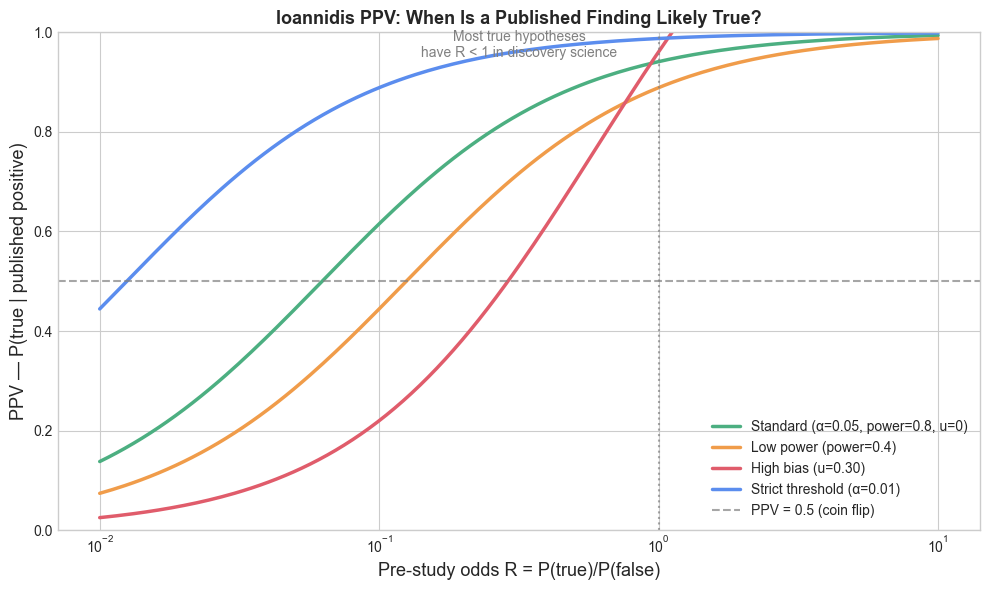

In [3]:
def ppv(R, alpha=0.05, power=0.8, u=0.0):
    """
    Positive Predictive Value (Ioannidis 2005).
    R: pre-study odds (P(true)/P(false))
    alpha: false positive rate
    power: 1 - beta
    u: bias parameter (0 = no bias)
    """
    beta = 1 - power
    numer = (1 - beta) * R + u * beta * R
    denom = (1 - beta) * R + alpha + u * (1 - alpha - (1-beta)*R)
    return numer / np.maximum(denom, 1e-10)

# PPV as a function of pre-study odds, for different study qualities
R_vals = np.logspace(-2, 1, 200)  # 1:100 to 10:1 odds

scenarios = [
    {'alpha': 0.05, 'power': 0.80, 'u': 0.00, 'label': 'Standard (α=0.05, power=0.8, u=0)', 'color': COLORS['tp']},
    {'alpha': 0.05, 'power': 0.40, 'u': 0.00, 'label': 'Low power (power=0.4)', 'color': COLORS['fn']},
    {'alpha': 0.05, 'power': 0.80, 'u': 0.30, 'label': 'High bias (u=0.30)', 'color': COLORS['fp']},
    {'alpha': 0.01, 'power': 0.80, 'u': 0.00, 'label': 'Strict threshold (α=0.01)', 'color': COLORS['tn']},
]

fig, ax = plt.subplots(figsize=(10, 6))
for s in scenarios:
    ppvs = [ppv(r, s['alpha'], s['power'], s['u']) for r in R_vals]
    ax.semilogx(R_vals, ppvs, lw=2.5, color=s['color'], label=s['label'])

ax.axhline(0.5, color='gray', ls='--', lw=1.5, alpha=0.7, label='PPV = 0.5 (coin flip)')
ax.axvline(1, color='gray', ls=':', lw=1.5, alpha=0.7)
ax.text(0.5, 0.95, 'Most true hypotheses\nhave R < 1 in discovery science', 
        ha='center', fontsize=10, color='gray', transform=ax.transAxes)

ax.set_xlabel('Pre-study odds R = P(true)/P(false)', fontsize=13)
ax.set_ylabel('PPV — P(true | published positive)', fontsize=13)
ax.set_title("Ioannidis PPV: When Is a Published Finding Likely True?", fontsize=13, fontweight='bold')
ax.legend(fontsize=10, loc='lower right')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('../assets/figures/ppv_ioannidis.png', dpi=120)
plt.show()

## 2. Mertonian Norm Violations → PPV Degradation

Each Mertonian norm violation increases bias $u$ or decreases power:

| Norm | Violation | Effect on PPV |
|------|----------|---------------|
| Disinterestedness | Financial conflict of interest | ↑ bias u |
| Communality | File drawer (unpublished negatives) | ↓ effective R |
| Organized skepticism | No replication required | ↑ u, ↓ power |
| Universalism | Identity-based rejection | Distorted sample |


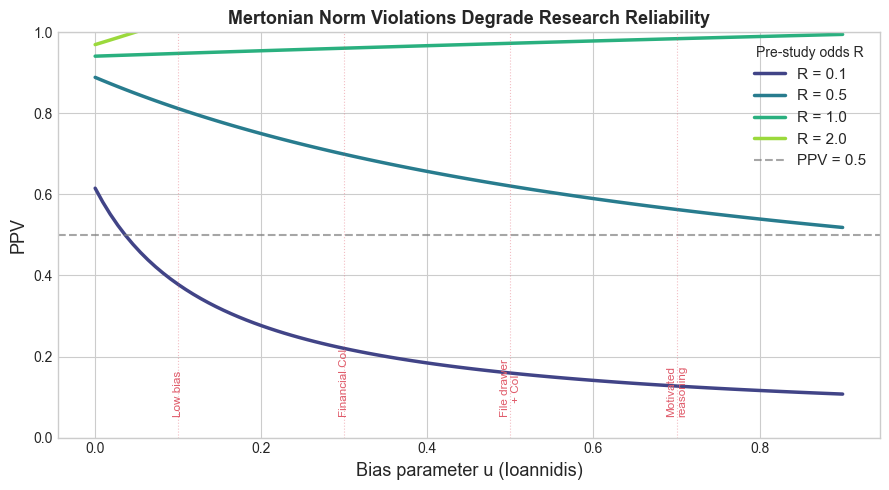

In [4]:
# PPV vs bias u for different prior odds
u_vals = np.linspace(0, 0.9, 100)
R_scenarios = [0.1, 0.5, 1.0, 2.0]

fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(R_scenarios)))

for R_s, c in zip(R_scenarios, colors):
    ppvs = [ppv(R_s, alpha=0.05, power=0.80, u=u) for u in u_vals]
    ax.plot(u_vals, ppvs, lw=2.5, color=c, label=f'R = {R_s}')

ax.axhline(0.5, color='gray', ls='--', lw=1.5, alpha=0.7, label='PPV = 0.5')

# Annotate Mertonian violations
violation_u = [0.10, 0.30, 0.50, 0.70]
violation_labels = ['Low bias', 'Financial CoI', 'File drawer\n+ CoI', 'Motivated\nreasoning']
for u_v, label in zip(violation_u, violation_labels):
    ax.axvline(u_v, color='#e05c6b', lw=0.8, alpha=0.4, ls=':')
    ax.text(u_v, 0.05, label, ha='center', fontsize=8.5, color='#e05c6b', rotation=90,
            va='bottom')

ax.set_xlabel('Bias parameter u (Ioannidis)', fontsize=13)
ax.set_ylabel('PPV', fontsize=13)
ax.set_title('Mertonian Norm Violations Degrade Research Reliability', fontsize=13, fontweight='bold')
ax.legend(fontsize=11, title='Pre-study odds R')
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('../assets/figures/ppv_merton.png', dpi=120)
plt.show()

## 3. The Deep Analogy: Science ↔ Machine Learning

The same mathematical structure underlies both:

| Concept | In Science (DSC 215) | In ML (DSC 240) |
|---------|---------------------|------------------|
| Ground truth | True effect exists | f*(x) exists |
| Measurement | Experiment / p-value | Empirical loss L̂_n |
| True quantity | Effect size / PPV | Expected loss L |
| Gap | False positive rate | Generalization gap |
| Controlled by | Power, α, u | n, |H|, VCdim |
| Failure mode | False discovery | Overfitting |
| Remedy | Replication | Test set / cross-validation |
| Theory | Ioannidis PPV | Hoeffding / VC bounds |

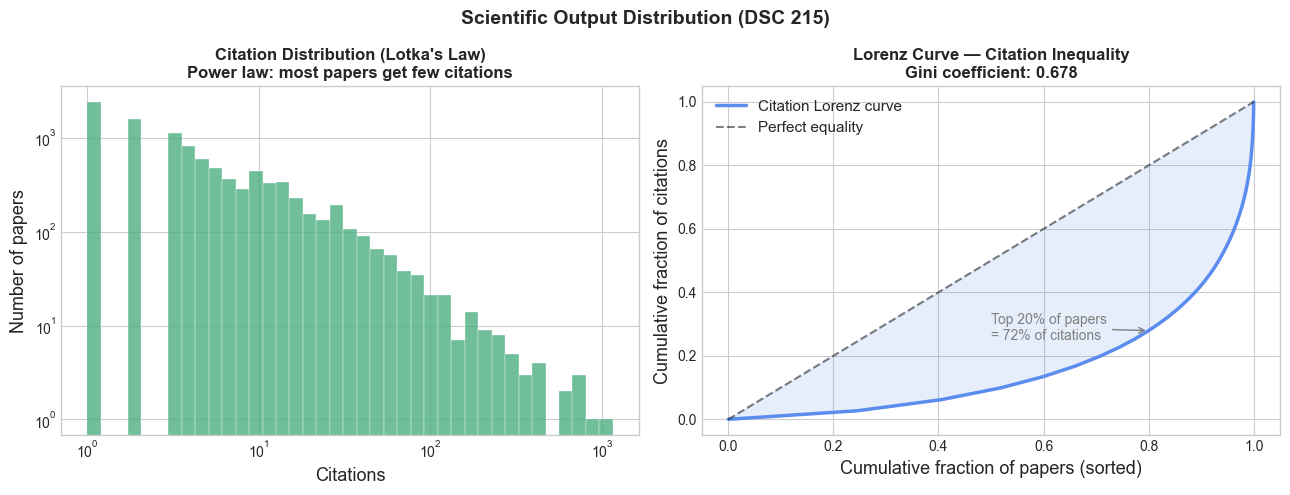

In [5]:
# Simulate the citation power-law (Lotka's Law)
# P(citations = k) ~ 1/k^alpha  (power law with alpha ~ 2)

np.random.seed(42)
n_papers = 10000
# Generate from Pareto distribution (power law)
citations = np.random.pareto(1.5, n_papers) * 5  # shape 1.5 → heavy tail
citations = citations.astype(int) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: histogram of citations
ax = axes[0]
bins = np.logspace(0, np.log10(citations.max()), 40)
ax.hist(citations, bins=bins, color=COLORS['tp'], alpha=0.8, edgecolor='white', lw=0.3)
ax.set_xscale('log'); ax.set_yscale('log')
ax.set_xlabel('Citations', fontsize=13)
ax.set_ylabel('Number of papers', fontsize=13)
ax.set_title("Citation Distribution (Lotka's Law)\nPower law: most papers get few citations", fontsize=12, fontweight='bold')

# Right: Lorenz curve
ax = axes[1]
sorted_cites = np.sort(citations)
cumulative_share = np.cumsum(sorted_cites) / sorted_cites.sum()
population_share = np.arange(1, n_papers+1) / n_papers

ax.plot(population_share, cumulative_share, color=COLORS['tn'], lw=2.5, label='Citation Lorenz curve')
ax.plot([0,1],[0,1], 'k--', lw=1.5, alpha=0.5, label='Perfect equality')

# Gini coefficient
gini = 1 - 2 * np.trapezoid(cumulative_share, population_share)
ax.fill_between(population_share, population_share, cumulative_share, alpha=0.15, color=COLORS['tn'])
ax.set_xlabel('Cumulative fraction of papers (sorted)', fontsize=13)
ax.set_ylabel('Cumulative fraction of citations', fontsize=13)
ax.set_title(f'Lorenz Curve — Citation Inequality\nGini coefficient: {gini:.3f}', fontsize=12, fontweight='bold')
ax.legend(fontsize=11)

# Highlight the 80/20 rule
idx_20 = np.searchsorted(population_share, 0.8)
ax.annotate(f'Top 20% of papers\n= {(1-cumulative_share[idx_20])*100:.0f}% of citations',
            xy=(0.8, cumulative_share[idx_20]), xytext=(0.5, 0.25),
            arrowprops=dict(arrowstyle='->', color='gray'), fontsize=10, color='gray')

plt.suptitle('Scientific Output Distribution (DSC 215)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../assets/figures/citation_powerlaw.png', dpi=120)
plt.show()

## Key Takeaways

1. **Both fields face the same core problem:** measuring something imperfectly (p-value / empirical loss) and making claims about the truth (effect exists / model generalizes).

2. **The gap is controlled by analogous quantities:**
   - Science: sample size (power), α level, bias u
   - ML: training set size n, hypothesis class complexity, regularization

3. **Replication in science ≡ test set in ML:** You can't evaluate generalization on the same data you optimized on.

4. **Lotka's Law:** Citation distributions follow power laws — highly skewed. Most results you encounter are from the top 10% of cited papers. Selection bias matters.

5. **Popper's falsifiability criterion ≡ non-trivial generalization:** A model that always predicts the majority class is 'unfalsifiable' in the sense that it's robust to any labeling pattern — it has learned nothing.